# WRF-Flow: Conditional Flow Matching for Precipitation Downscaling

## Problem Statement

Mountain precipitation is a critical input for climate adaptation planning, water resource management, and avalanche hazard assessment. However, global climate models operate at ~100 km resolution and systematically fail to represent orographic precipitation in complex terrain. Dynamical downscaling (running regional weather models like WRF at high resolution forced by coarse climate data) can capture these effects but requires months of computation per scenario.

**WRF-Flow** addresses this challenge by learning a probabilistic generative model that maps coarse-resolution climate model output and high-resolution topography to plausible high-resolution precipitation fields. The model generates ensembles of physically consistent downscaled precipitation in seconds, rather than months, enabling probabilistic uncertainty quantification for climate adaptation.

## Dataset

Training data comes from the Weather Research and Forecasting (WRF) model configured at 4 km resolution over the St. Elias and Chugach mountain ranges in Alaska. The dataset includes:
- **Precipitation fields**: Maximum 3-day snowfall from historical (CFSR reanalysis, 1981-2010) and future (GFDL and CCSM climate models, 2031-2060) atmospheric simulations
- **Topography**: High-resolution digital elevation model at 4 km resolution
- **Train/test split**: 120 time steps for training, 30+ for evaluation

The dataloader performs three key operations:
1. **Tiling**: Divides the regional domain into overlapping 64×64 pixel patches
2. **Decimation**: Coarsens high-resolution precipitation by 4× (simulating 64 km climate model resolution) via block averaging
3. **Conditioning**: Combines coarse precipitation, high-resolution topography, and validity masks as model inputs

In [1]:
import torch
import numpy as np
import os
import rasterio
from notebook_utils import block_mean_tensor_vectorized

class WRFDataLoader:
    def __init__(self, data_dir='./data',swe_factor=100.0,hgt_factor=300.0):
        self.data_dir = data_dir
        self.swe_factor = swe_factor
        self.hgt_factor = hgt_factor
    
        # Ensure data directory exists
        if not os.path.exists(self.data_dir):
            print(f"Creating data directory: {self.data_dir}")
            os.makedirs(self.data_dir)
    
        rasters = []
        filtered_files = []
        for f in os.listdir(data_dir):
            if '.tif' in f and 'HGT' not in f and 'aux' not in f:
                filtered_files.append(f)
        for f in filtered_files:
            try:
                data = rasterio.open(f'{data_dir}/{f}')
            except rasterio.RasterioIOError:
                continue
            snow = data.read().squeeze()[1:-1,1:-1]
            rasters.append(snow)
    
        self.rasters = np.stack(rasters,axis=0)
        self.rasters[self.rasters==-999] = np.nan
        self.rasters /= swe_factor
    
        self.rasters_test = self.rasters[120:]
        self.rasters = self.rasters[:120]
    
        self.d,self.h,self.w = self.rasters.shape
        self.d_test, _, _ = self.rasters_test.shape
    
        hgt = rasterio.open(f'{data_dir}/geo_southeast_4km_HGT.tif').read().squeeze()
        self.hgt = hgt[1:-1,1:-1] / hgt_factor
    
    def sample(self, n, n_pix=64, device='cpu',test_set=False):
    
        if test_set:
            d = self.d_test
        else:
            d = self.d
    
        images = []
        heights = []
        crses = []
        while len(images) < n:
          index = np.random.randint(d)
          h0 = np.random.randint(self.h - n_pix)
          w0 = np.random.randint(self.w - n_pix)
          if test_set:
              img = torch.tensor(self.rasters_test[index,h0:h0+n_pix,w0:w0+n_pix])
          else:
              img = torch.tensor(self.rasters[index,h0:h0+n_pix,w0:w0+n_pix])
          if torch.isnan(img).sum() < 0.3*n_pix**2:
              images.append(img)
              heights.append(torch.tensor(self.hgt[h0:h0+n_pix,w0:w0+n_pix]))
    
        image_batch = torch.stack(images).reshape(-1,1,n_pix,n_pix)
        hgt_batch = torch.stack(heights).reshape(-1,1,n_pix,n_pix)
        crs_batch = block_mean_tensor_vectorized(image_batch,4)
    
        return image_batch,hgt_batch,crs_batch
    
    def pull(self, locs, n_pix=64, device='cpu',test_set=False):
    
        if test_set:
            d = self.d_test
        else:
            d = self.d
    
        images = []
        heights = []
        crses = []
        for index,h0,w0 in locs:
          if test_set:
              img = torch.tensor(self.rasters_test[index,h0:h0+n_pix,w0:w0+n_pix])
          else:
              img = torch.tensor(self.rasters[index,h0:h0+n_pix,w0:w0+n_pix])
          if torch.isnan(img).sum() < 0.3*n_pix**2:
              images.append(img)
              heights.append(torch.tensor(self.hgt[h0:h0+n_pix,w0:w0+n_pix]))
    
        image_batch = torch.stack(images).reshape(-1,1,n_pix,n_pix)
        hgt_batch = torch.stack(heights).reshape(-1,1,n_pix,n_pix)
        crs_batch = block_mean_tensor_vectorized(image_batch,4)
    
        return image_batch,hgt_batch,crs_batch

n_pix = 64
target_model = WRFDataLoader(data_dir='./data/sx3/')
device = 'cuda'



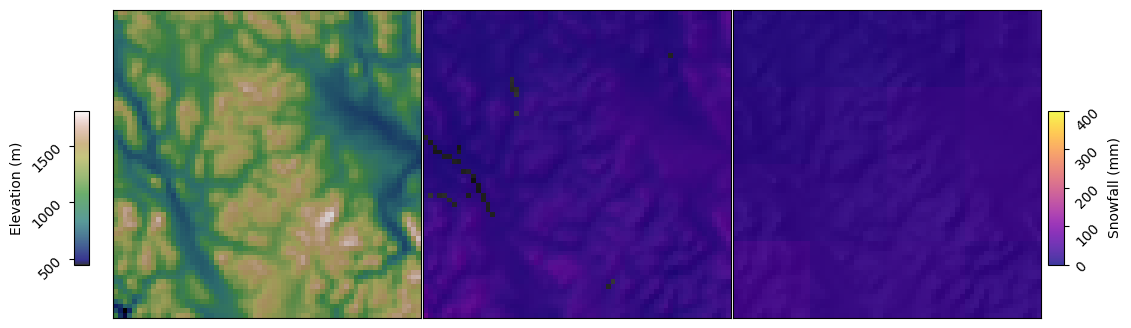

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_blended_hillshade(z_sample,ax,cmap=plt.cm.terrain,ve=1,dx=4000,vmin=-2.5,vmax=2.5):
   ls = LightSource(azdeg=315, altdeg=45)
   rgb = ls.shade(z_sample.numpy(), cmap=cmap, 
                  blend_mode='overlay', vert_exag=ve, 
                  dx=dx, dy=dx,vmin=vmin,vmax=vmax)
   ax.imshow(rgb)
    
hgt_factor = target_model.hgt_factor
swe_factor = target_model.swe_factor
x,h,c = target_model.sample(1,n_pix=n_pix)

fig,axs = plt.subplots(ncols=3)
for ax in axs.ravel():
    plot_blended_hillshade(h.cpu().squeeze()*swe_factor,ax,cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

c_hgt = axs[0].imshow(h.squeeze()*hgt_factor,cmap=plt.cm.gist_earth,alpha=0.8)
_     = axs[1].imshow(x.squeeze()*swe_factor,cmap=plt.cm.plasma,vmin=0.0,vmax=400.0,alpha=0.8)
c_swe = axs[2].imshow(c.squeeze()*swe_factor,cmap=plt.cm.plasma,vmin=0.0,vmax=400.0,alpha=0.8)

cax = inset_axes(axs[0], width="5%", height="50%", loc='lower left',bbox_to_anchor=(-0.15, 0.15, 1, 1), bbox_transform=axs[0].transAxes)
cbar = plt.colorbar(c_hgt,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('Elevation (m)')

cax = inset_axes(axs[2], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.15, 1, 1), bbox_transform=axs[2].transAxes)
cbar = plt.colorbar(c_swe,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.set_label('Snowfall (mm)')

fig.subplots_adjust(wspace=0,hspace=0)
fig.set_size_inches(12,4)


# Flow Matching Objective

Conditional flow matching (CFM) is a state-of-the-art generative model framework that learns to map from noise to data by training a neural network to predict velocity fields in probability space. 

Unlike diffusion models (which reverse a fixed noise schedule), flow matching uses **optimal transport** probability paths:
- Marginal at t=0: Pure noise distribution (gaussian)
- Marginal at t=1: Data distribution (WRF precipitation conditioned on topography and coarse climate)
- The velocity field v(x_t, t | condition) interpolates between these distributions

The model is trained by:
1. Sampling a high-resolution WRF precipitation field (x₁)
2. Sampling noise (x₀)
3. Interpolating along the OT path: x_t = σ(t)·x₀ + (1-σ(t))·x₁
4. Predicting the target velocity: v_target = x₁ - (1-σ₀)·x₀
5. Minimizing: ||v_pred - v_target||² (masked to ignore missing data)

**Advantages over diffusion**: Faster convergence, more direct optimization target, flexible probability paths adapted to the data geometry.

In [3]:
class OTProbabilityPaths:
    def __init__(self,sigma_0):
        self.sigma_0 = sigma_0

    def get_mu(self,x1,t):
        return x1*t

    def get_sigma(self,t):
        return 1 - (1 - self.sigma_0)*t

    def get_psi(self,x,x1,t):
        return self.get_sigma(t)*x + self.get_mu(x1,t)

    def get_v_target(self,x,x1,t):
        return x1 - (1-self.sigma_0)*x0

fm = OTProbabilityPaths(1e-3)

# Velocity Network Architecture

The velocity network is a **U-Net** with self-attention, adapted from image generation literature. The architecture:
- **Input**: 4 channels = [x_t (partially denoised), elevation, coarse climate, validity mask]
- **Output**: 1 channel = predicted velocity field
- **Design**: Hierarchical feature extraction via downsampling, bottleneck processing, and upsampling with skip connections
- **Time conditioning**: Sinusoidal embeddings of the time variable t injected at each ResBlock
- **Attention**: Self-attention at 16×16 resolution to capture long-range spatial dependencies in precipitation patterns
- **Normalization**: GroupNorm(32) for stability with variable batch sizes

This architecture balances:
- **Expressiveness**: Multiple resolution levels capture multi-scale precipitation structure
- **Efficiency**: ~8M parameters, trainable on consumer GPUs
- **Physical grounding**: Skip connections preserve topographic features; attention learns elevation-dependent precipitation relationships

In [115]:
from models.unet_models import UNet

in_channels = 4

v_model = UNet(
        in_channels=in_channels,
        model_channels=64,
        out_channels=1,
        num_res_blocks=2,
        attention_resolutions=(16,),  # Self-attention at 16x16 resolution
        channel_mult=(1, 1, 2, 3, 4,),   # Four resolution levels: 64, 32, 16, 8, 4
        dropout=0.1,
    ).to(device)

# Training the Velocity Network

The velocity network is trained via gradient descent on paired (coarse, fine, topography) triplets:
- **Optimizer**: Adam with learning rate 2×10⁻⁴
- **Batch size**: 24 patches
- **Iterations**: 10,000 steps (~2.5 epochs over 120 training samples with random tiling)
- **Loss**: Masked MSE between predicted and target velocities
  - Only valid pixels (non-masked regions) contribute to the loss
  - Gradient computation prevents overfitting to missing data

Set `TRAIN=True` to train from scratch (requires GPU, ~30 minutes). Set `TRAIN=False` to load pre-trained weights. Checkpoints saved every 100 steps.

In [116]:
TRAIN = True
if TRAIN:
    optimizer = torch.optim.Adam(v_model.parameters(),lr=1e-4)
    
    batch_size = 24
    n_steps = 10000

    beta=torch.distributions.beta.Beta(2,1)
    v_model.train()
    for i in range(n_steps):
        # Clear gradient buffer
        optimizer.zero_grad()

        # Sample from data points and associated conditioning
        x1,h,c = (f.to(device) for f in target_model.sample(batch_size,n_pix=n_pix))

        # mask any coarse resolution data
        c[c.isnan()] = 0.0

        # Build mask for unresolved high-res data - this will be a signal to ignore
        m = x1.isnan()  

        # Eliminate any nans
        x1[m] = 0.0

        # Sample time in [0,1]
        #t = torch.rand(x1.shape[0],1,1,1,device=device)
        t = beta.sample((x1.shape[0],1,1,1)).to(device)
        
        # Sample noise
        x0 = torch.randn_like(x1,device=device)

        # Extrapolate denoised image
        xt = fm.get_psi(x0,x1,t)

        # Build conditions - 
        # partially denoised image, topography, coarse climate, mask
        x_cat = torch.cat((xt,h,c,m),dim=1)

        # Predict velocity
        v_pred = v_model(x_cat,t.squeeze())

        # Get conditional velocity
        v_target = fm.get_v_target(x0,x1,t)

        # Compute loss, backprop, step
        loss = ((v_pred - v_target)**2)[~m].mean()
        loss.backward()
        optimizer.step()
        
        if i%1000==0:
            print(i,loss.item())
            torch.save(v_model,f'./checkpoints/conditional_snowfall_model_latest.pt')
            torch.save(v_model,f'./checkpoints/conditional_snowfall_model_{i:04d}.pt')
else:
    v_model = torch.load('./checkpoints/conditional_snowfall_model_beta.pt',weights_only=False)

0 1.8254705667495728
100 0.3518771827220917
200 0.25326523184776306
300 0.23108921945095062
400 0.31254464387893677
500 0.1948973834514618
600 0.2350924164056778
700 0.18133807182312012
800 0.33042702078819275
900 0.21738658845424652
1000 0.2782319486141205
1100 0.1963372677564621
1200 0.1803414672613144
1300 0.17613650858402252
1400 0.22168861329555511
1500 0.16217796504497528
1600 0.2449578493833542
1700 0.20258358120918274
1800 0.18720918893814087
1900 0.1746007651090622
2000 0.1781761795282364
2100 0.15640509128570557
2200 0.21526587009429932
2300 0.20995332300662994
2400 0.18689440190792084


KeyboardInterrupt: 

# Generate some samples via ODE integration.  Applied to test set low-res climate for comparison.

In [117]:
from torchdiffeq import odeint

# Number of samples to generate
n_samples = 3

# Draw some test set samples from a few tiles
xtrue,h,c = (f.to(device) for f in 
               target_model.pull([(29,0,0),(11,20,100),(5,50,220)],
               test_set=True))

# Mask coarse conditioning with nans
c[c.isnan()] = 0.0

# Set velocity model to eval mode
v_model.eval()

# Sample some noise
x0 = torch.randn(n_samples,1,n_pix,n_pix,device=device)

# Define the right-hand side for the flow-matching ODE
def func(t,x):
    xin = torch.cat((x,h,c,torch.zeros_like(x)),dim=1)
    return v_model(xin,t.reshape(1))

# Define integration interval
t = torch.linspace(0,1,50,device=device)

# Generate new samples via integration of the flow-matching ODE
# From noise initial conditions along trajectories defined
# by the velocity model
with torch.no_grad():
    trajectories = odeint(func, x0, t,rtol=1e-5,atol=1e-5)

# Finished samples occur at final time step
xsamp = trajectories[-1]


# Visualize in comparison to ground-truth WRF runs.  

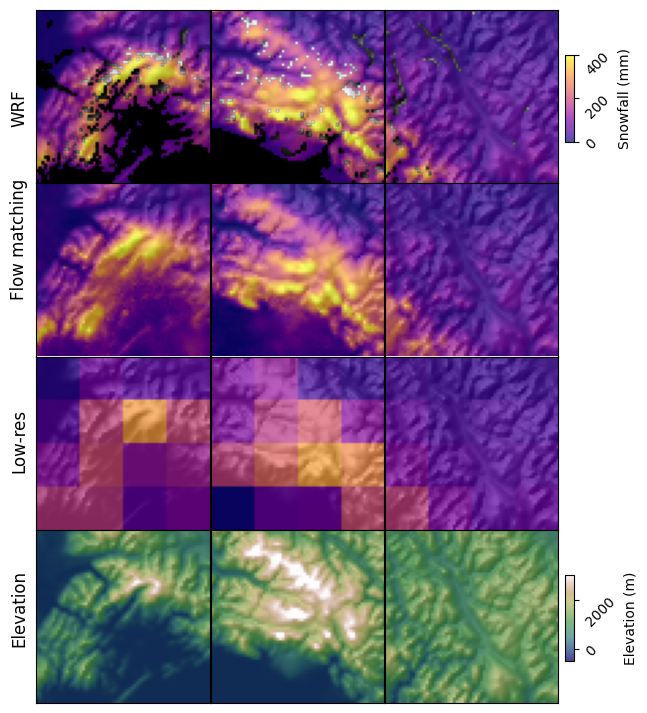

In [118]:
from matplotlib.colors import LightSource
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


fig,axs = plt.subplots(nrows=4,ncols=n_samples)
for i in range(n_samples):
    plot_blended_hillshade(h[i].cpu().squeeze()*hgt_factor,axs[0,i],cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    plot_blended_hillshade(h[i].cpu().squeeze()*hgt_factor,axs[1,i],cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    plot_blended_hillshade(h[i].cpu().squeeze()*hgt_factor,axs[3,i],cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    plot_blended_hillshade(h[i].cpu().squeeze()*hgt_factor,axs[2,i],cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)

    cswe = axs[0,i].imshow(xtrue[i].cpu().squeeze()*swe_factor,vmin=0,vmax=400,cmap=plt.cm.plasma,alpha=0.7)
    _    = axs[1,i].imshow(xsamp[i].cpu().squeeze()*swe_factor,vmin=0,vmax=400,cmap=plt.cm.plasma,alpha=0.7)
    _    = axs[2,i].imshow(    c[i].cpu().squeeze()*swe_factor,vmin=0,vmax=400,cmap=plt.cm.plasma,alpha=0.7)
    chgt = axs[3,i].imshow(    h[i].cpu().squeeze()*hgt_factor,cmap=plt.cm.gist_earth,vmin=-500,vmax=3000,alpha=0.7)


    if i==n_samples-1:
        cax = inset_axes(axs[0,i], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.2, 1, 1), bbox_transform=axs[0,i].transAxes)
        cbar = plt.colorbar(cswe,cax=cax,orientation='vertical')
        cbar.ax.tick_params(rotation=45)
        cbar.set_label('Snowfall (mm)')

        cax = inset_axes(axs[3,i], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.2, 1, 1), bbox_transform=axs[3,i].transAxes)
        cbar = plt.colorbar(chgt,cax=cax,orientation='vertical')
        cbar.ax.tick_params(rotation=45)
        cbar.set_label('Elevation (m)')

for ax in axs.ravel():
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

axs[0,0].set_title('WRF', rotation='vertical',x=-0.1,y=0.3)
axs[1,0].set_title('Flow matching', rotation='vertical',x=-0.1,y=0.3)
axs[2,0].set_title('Low-res', rotation='vertical',x=-0.1,y=0.3)
axs[3,0].set_title('Elevation', rotation='vertical',x=-0.1,y=0.3)

fig.set_size_inches(9*3/4.,9)
fig.subplots_adjust(wspace=0,hspace=0)

# Demonstrate the variability in predicted samples

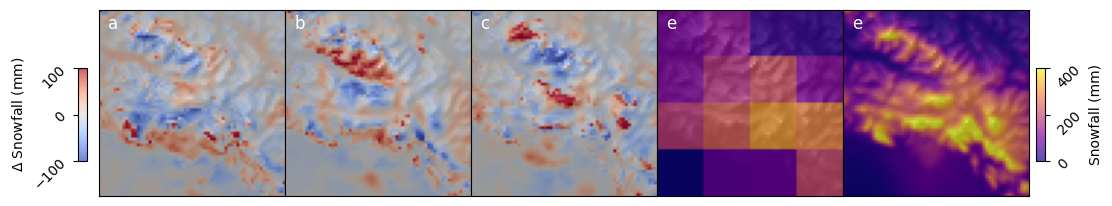

In [109]:
n_samples = 50
xtrue,h,c = (f.to(device) for f in 
               target_model.pull([(11,20,100)],
               test_set=True))

c[c.isnan()] = 0.0

xtrue = torch.tile(xtrue,(n_samples,1,1,1))
h = torch.tile(h,(n_samples,1,1,1))
c = torch.tile(c,(n_samples,1,1,1))

v_model.eval()

x0 = torch.randn(n_samples,1,n_pix,n_pix,device=device)

def func(t,x):
    xin = torch.cat((x,h,c,torch.zeros_like(x)),dim=1)
    return v_model(xin,t.reshape(1))

t = torch.linspace(0,1,10,device=device)
with torch.no_grad():
    trajectories = odeint(func, x0, t,rtol=1e-5,atol=1e-5)

xsamp = trajectories[-1]
xmean = xsamp.mean(dim=0)
xdelta = xsamp - xmean

fig,axs = plt.subplots(nrows=1,ncols=5)
axs = axs.ravel()
letters = 'abcde'
lc = 0

for ax in axs.ravel():
    plot_blended_hillshade(h[i].cpu().squeeze()*swe_factor,ax,cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    

for i in range(3):    
    c_delta = axs[i].imshow(xdelta[i].cpu().squeeze()*swe_factor,vmin=-100,vmax=100,alpha=0.7,cmap=plt.cm.coolwarm)

    axs[i].text(0.05, 0.9, letters[lc],color='white',transform=axs[i].transAxes,fontsize=12)
    lc+=1

cax = inset_axes(axs[0], width="5%", height="50%", loc='lower left',bbox_to_anchor=(-0.15, 0.15, 1, 1), bbox_transform=axs[0].transAxes)
cbar = plt.colorbar(c_delta,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)#,color='white', labelcolor='white')
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('$\\Delta$ Snowfall (mm)')

axs[3].imshow(c[0].cpu().squeeze()*swe_factor,vmin=0,vmax=400,alpha=0.7,cmap=plt.cm.plasma)
axs[3].text(0.05, 0.9, letters[4],color='white',transform=axs[3].transAxes,fontsize=12)

c_abs = axs[4].imshow(xmean.cpu().squeeze()*swe_factor,vmin=0,vmax=400,alpha=0.7,cmap=plt.cm.plasma)
cax = inset_axes(axs[4], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.15, 1, 1), bbox_transform=axs[4].transAxes)
cbar = plt.colorbar(c_abs,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.set_label('Snowfall (mm)')

axs[4].text(0.05, 0.9, letters[4],color='white',transform=axs[4].transAxes,fontsize=12)

fig.set_size_inches(12,6)
fig.subplots_adjust(wspace=0,hspace=0)

# Ensemble Statistics and Uncertainty Quantification

Conditional flow matching generates multiple samples from the same coarse forcing and topography. The ensemble captures:
- **Mean field**: Central estimate of expected high-resolution precipitation
- **Standard deviation**: Spatial pattern of uncertainty, typically higher over complex terrain and lower over homogeneous regions
- **Spread-skill relationship**: Areas of high uncertainty should correspond to areas where observations diverge from coarse-scale forcing

These statistics are fundamental to assessing whether the model's confidence (ensemble spread) is calibrated to actual forecast errors—a critical requirement for decision-making in infrastructure planning and hazard assessment.

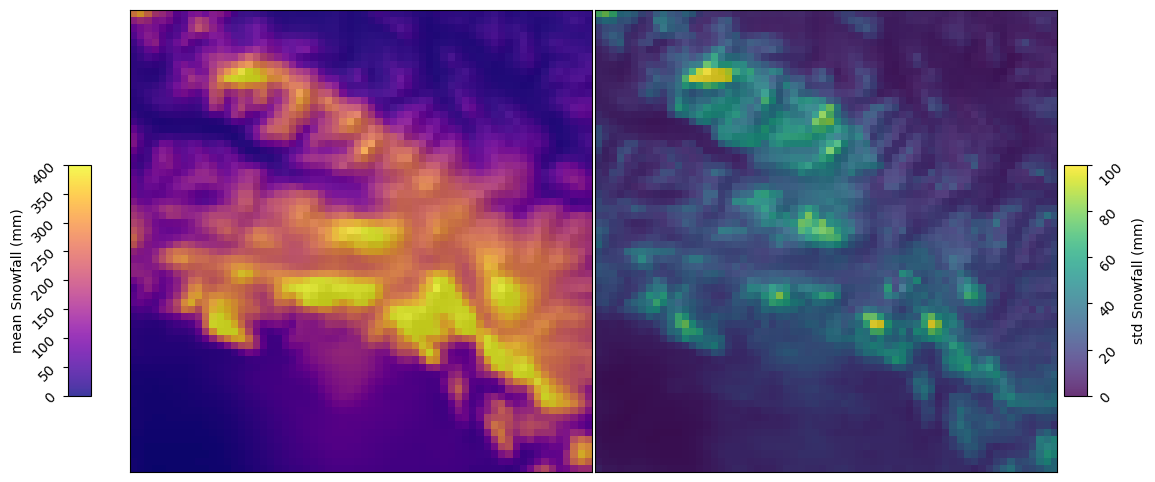

In [110]:
fig,axs = plt.subplots(nrows=1,ncols=2)
for ax in axs.ravel():
    plot_blended_hillshade(h[i].cpu().squeeze()*swe_factor,ax,cmap=plt.cm.grey,vmin=0,vmax=3000,ve=100)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

c_mean = axs[0].imshow(xsamp.mean(axis=0).squeeze().cpu()*swe_factor,vmin=0,vmax=400,alpha=0.8,cmap=plt.cm.plasma)
c_std  = axs[1].imshow(xsamp.std(axis=0).squeeze().cpu()*swe_factor,vmin=0,vmax=100,alpha=0.8)

cax = inset_axes(axs[0], width="5%", height="50%", loc='lower left',bbox_to_anchor=(-0.15, 0.15, 1, 1), bbox_transform=axs[0].transAxes)
cbar = plt.colorbar(c_mean,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('mean Snowfall (mm)')

cax = inset_axes(axs[1], width="5%", height="50%", loc='lower left',bbox_to_anchor=(1.0, 0.15, 1, 1), bbox_transform=axs[1].transAxes)
cbar = plt.colorbar(c_std,cax=cax,orientation='vertical')
cbar.ax.tick_params(rotation=45)
cbar.set_label('std Snowfall (mm)')


fig.set_size_inches(12,6)
fig.subplots_adjust(wspace=0,hspace=0)

# Evaluation: Continuous Ranked Probability Score (CRPS)

The **Continuous Ranked Probability Score (CRPS)** measures the calibration of probabilistic predictions. For an ensemble forecast with members {f₁, f₂, ..., f_N} and observation y:

CRPS = E[|F - y|] - ½ E[|F - F'|]

where the first term is the mean absolute error to the observation and the second term is the average pairwise distance in the ensemble (ensemble spread).

**Interpretation**:
- Lower CRPS = better calibrated forecast
- Decomposes into reliability (ensemble vs observation) and resolution (ensemble spread)

CRPS is best interpreted as a relative metric.  To have something to compare to, we adopt a simple statistical downscaling technique (noting that there are much more complex techniques than this one that might produce better forecasts).  First, we perform bicubic interpolation of the coarse climate field to produce a smooth version.  Then, we form the pixelwise linear model 
$$
x_{pred} = \omega_0 z + \omega_1 c + \omega_2.
$$
To infer the model parameters, we solve a simple bayesian linear regression problem, in which we assume a combination of fully correlated and uncorrelated errors.  Ensembles can then be formed by sampling from the resulting posterior distribution over the linear model's parameters. 

In [119]:
# To compare crps, we need an alternative model
x1,h,c = (f.to(device) for f in target_model.sample(60,n_pix=n_pix))
c[c.isnan()] = 0.0
scale = 16

import torch.nn.functional as F
c_interp = F.interpolate(c[:,:,::scale,::scale], scale_factor=scale, mode='bicubic', align_corners=False)

h_flat = h.ravel()
c_flat = c_interp.ravel()
x1_flat = x1.ravel()

m_flat = x1_flat.isnan()

h_flat = h_flat[~m_flat]
c_flat = c_flat[~m_flat]
x1_flat = x1_flat[~m_flat]

phi = torch.vstack((h_flat,c_flat,torch.ones(len(h_flat),device=device))).T

tau_obs = 100
v = torch.ones(phi.shape[0],1,device=device)
K = tau_obs*(phi.T @ phi - (phi.T @ v) @ (v.T @ phi)/(1 + v.T @ v))
z = tau_obs*(phi.T @ (x1_flat - v @ (v.T @ x1_flat)/(1 + v.T @ v)).T)

L = torch.linalg.cholesky(K)
w_opt = torch.linalg.solve(K,z)

In [124]:
torch.manual_seed(0)

def compute_crps(ensemble_samples, observations, axis=None):
    """
    Compute Continuous Ranked Probability Score.
    
    Args:
        ensemble_samples: Array of shape (n_members, *spatial_dims) 
                         or (n_members, n_locations)
        observations: Array of shape (*spatial_dims,) or (n_locations,)
        axis: Axis over which to compute ensemble statistics (default: axis 0)
    
    Returns:
        CRPS score(s) - lower is better
    """
    # First term: mean absolute error to observation
    ae = np.abs(ensemble_samples - observations)
    term1 = np.mean(ae, axis=0)
    
    # Second term: half the mean pairwise ensemble distance
    # For computational efficiency, compute as: 
    # 0.5 * E[|F_i - F_j|] = sum of pair distances / (2 * n_pairs)
    n_members = ensemble_samples.shape[0]
    term2 = np.zeros_like(term1)
    
    for i in range(n_members):
        for j in range(i + 1, n_members):
            term2 += np.abs(ensemble_samples[i] - ensemble_samples[j])
    
    term2 = term2 / (n_members * (n_members - 1) / 2.0)
    
    return term1 - 0.5 * term2


# Generate a large ensemble for evaluation
n_eval_samples = 50

# Draw test set samples
#xtrue_eval, h_eval, c_eval = (f.to(device) for f in 
#                               target_model.pull([(29,0,0), (11,20,100), (5,50,220)],
#                               test_set=True))

xtrue_eval, h_eval, c_eval = (f.to(device) for f in 
                               target_model.sample(5,n_pix=n_pix,
                               test_set=True))

mask = xtrue_eval.isnan()

# Prepare tensors for ensemble generation
c_eval[c_eval.isnan()] = 0.0
n_tiles = xtrue_eval.shape[0]

# Expand for ensemble
xtrue_ensemble = xtrue_eval.repeat(n_eval_samples, 1, 1, 1)
h_ensemble = h_eval.repeat(n_eval_samples, 1, 1, 1)
c_ensemble = c_eval.repeat(n_eval_samples, 1, 1, 1)

v_model.eval()

# Generate ensemble via ODE integration
x0_eval = torch.randn(n_eval_samples * n_tiles, 1, n_pix, n_pix, device=device)

def func_eval(t, x):
    xin = torch.cat((x, h_ensemble.reshape(-1, 1, n_pix, n_pix), 
                     c_ensemble.reshape(-1, 1, n_pix, n_pix),
                     torch.zeros_like(x)), dim=1)
    return v_model(xin, t.reshape(1))

t_eval = torch.linspace(0, 1, 100, device=device)

with torch.no_grad():
    trajectories_eval = odeint(func_eval, x0_eval, t_eval, rtol=1e-5, atol=1e-5)

xsamp_ensemble = trajectories_eval[-1].reshape(n_eval_samples, n_tiles, 1, n_pix, n_pix)

# Compute CRPS
crps_flow = compute_crps(
    xsamp_ensemble.cpu().numpy() * swe_factor,
    xtrue_eval.cpu().numpy() * swe_factor
)

# Baseline: CRPS from bicubic interpolated coarse climate
c_bicubic = F.interpolate(c_ensemble[:,:,::16,::16], scale_factor=16, mode='bicubic', align_corners=False)
noise = torch.randn(3,250,device=device)
w_samples = w_opt + torch.linalg.solve_triangular(L,noise,upper=False)
xsamp_bicubic = (h_ensemble * w_samples[0].reshape(-1,1,1,1) + 
                 c_bicubic*w_samples[1].reshape(-1,1,1,1) + 
                 w_samples[2].reshape(-1,1,1,1)).reshape(n_eval_samples,n_tiles,1,n_pix,n_pix)

crps_coarse = compute_crps(
    xsamp_bicubic.cpu().numpy() * swe_factor,
    xtrue_eval.cpu().numpy() * swe_factor
)

print(f"WRF-Flow CRPS (ensemble of {n_eval_samples}):")
print(f"  Mean CRPS: {np.nanmean(crps_flow):.2f} mm")
print(f"  Std CRPS:  {np.nanstd(crps_flow):.2f} mm")
print(f"\nCoarse baseline CRPS (interpolated):")
print(f"  Mean CRPS: {np.nanmean(crps_coarse):.2f} mm")
print(f"  Improvement: {(np.nanmean(crps_coarse) - np.nanmean(crps_flow)) / np.nanmean(crps_coarse) * 100:.1f}%")

WRF-Flow CRPS (ensemble of 50):
  Mean CRPS: 6.40 mm
  Std CRPS:  7.58 mm

Coarse baseline CRPS (interpolated):
  Mean CRPS: 19.33 mm
  Improvement: 66.9%


The raw numbers imply a fairly sizeable improvement in forecast skill.  We can evaluate CRPS scores pointwise to get a sense for where flow matching produces better forecasts.

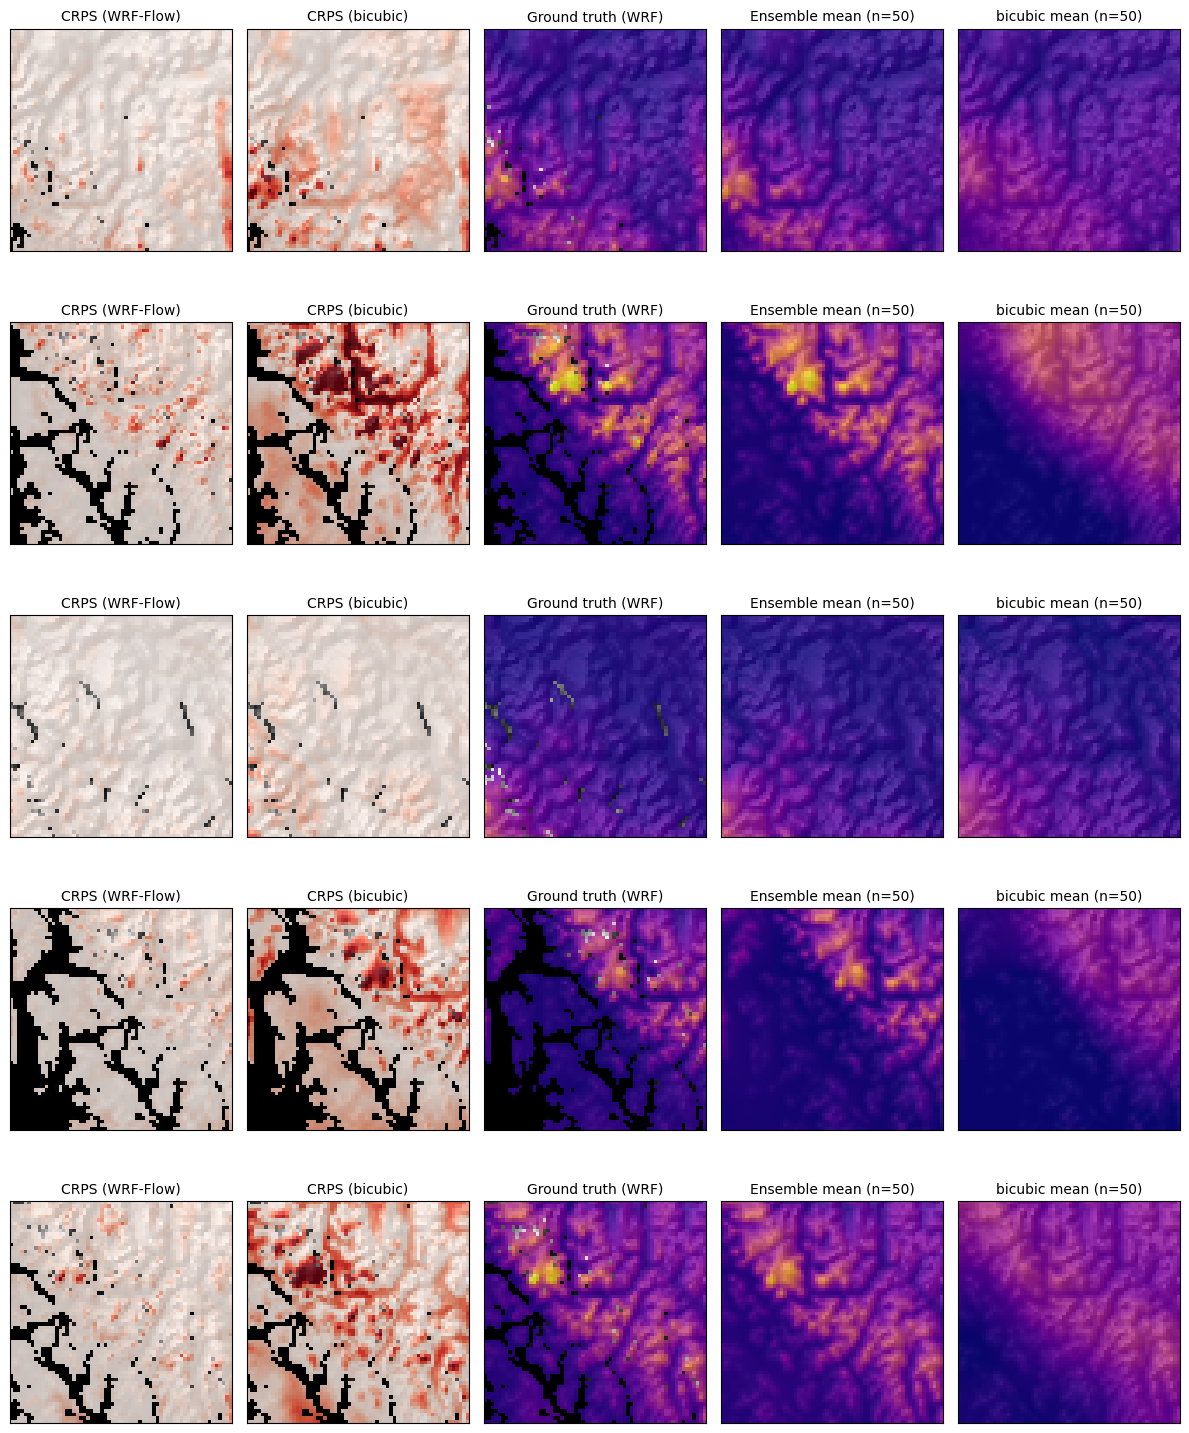

In [125]:
# Spatial visualization of CRPS
fig, axs = plt.subplots(nrows=n_tiles, ncols=5, figsize=(12, 3*n_tiles))

if n_tiles == 1:
    axs = axs.reshape(1, -1)

for tile_idx in range(n_tiles):
    # Plot elevation as background
    for ax_idx in range(5):
        plot_blended_hillshade(h_eval[tile_idx].cpu().squeeze() * hgt_factor, 
                              axs[tile_idx, ax_idx], 
                              cmap=plt.cm.grey, vmin=0, vmax=3000, ve=100)
        axs[tile_idx, ax_idx].xaxis.set_visible(False)
        axs[tile_idx, ax_idx].yaxis.set_visible(False)
    
    # CRPS spatial map
    c_crps = axs[tile_idx, 0].imshow(crps_flow[tile_idx, 0], 
                                      cmap=plt.cm.Reds, vmin=0, vmax=100, alpha=0.8)
    axs[tile_idx, 0].set_title('CRPS (WRF-Flow)', fontsize=10)

    # CRPS spatial map
    c_crps = axs[tile_idx, 1].imshow(crps_coarse[tile_idx, 0], 
                                      cmap=plt.cm.Reds, vmin=0, vmax=100, alpha=0.8)
    axs[tile_idx, 1].set_title('CRPS (bicubic)', fontsize=10)
    
    # True observation
    c_true = axs[tile_idx, 2].imshow(xtrue_eval[tile_idx].squeeze().cpu() * swe_factor,
                                      cmap=plt.cm.plasma, vmin=0, vmax=400, alpha=0.8)
    axs[tile_idx, 2].set_title('Ground truth (WRF)', fontsize=10)
    
    # Ensemble mean
    c_mean = axs[tile_idx, 3].imshow(np.mean(xsamp_ensemble[:, tile_idx, 0].cpu().numpy() * swe_factor, axis=0),
                                      cmap=plt.cm.plasma, vmin=0, vmax=400, alpha=0.8)
    axs[tile_idx, 3].set_title(f'Ensemble mean (n={n_eval_samples})', fontsize=10)

    # Ensemble mean
    c_mean = axs[tile_idx, 4].imshow(np.mean(xsamp_bicubic[:, tile_idx, 0].cpu().numpy() * swe_factor, axis=0),
                                      cmap=plt.cm.plasma, vmin=0, vmax=400, alpha=0.8)
    axs[tile_idx, 4].set_title(f'bicubic mean (n={n_eval_samples})', fontsize=10)

fig.tight_layout()
plt.show()

# Evaluation: Power Spectral Density (PSD)

The **radially-averaged 2D power spectral density** complements CRPS by evaluating the *spatial structure* of downscaled fields, independent of point-wise errors. While CRPS measures forecast calibration (does the ensemble bracket the truth?), PSD reveals whether the model reproduces physical multi-scale variance correctly.

## What PSD shows

A 2D FFT of each field decomposes variance into spatial scales (wavelengths). By radially averaging power in annular wavenumber bands, we obtain a 1D spectrum: power vs. wavelength in km.

- **Models that blur precipitation** (over-smooth) show a **spectral deficit** at small scales (< 10 km)
- **Models that hallucinate noise** show a **spectral excess** at small scales
- **WRF-Flow ensemble spread** across members reveals whether the model's uncertainty is reasonable at each scale

## Plot interpretation

A log-log plot of power vs. wavelength (increasing left→right from small to large scales):
- **WRF truth**: solid dark line — reference observation
- **WRF-Flow**: solid colored line (ensemble mean) + shaded band (±1 std across 50 members)
- **Bicubic+lapse-rate baseline**: dashed line — what we're improving upon

The baseline is typically too smooth (spectral deficit below ~8 km) because it's deterministic and spatially smooth. WRF-Flow should show stronger power at small scales (better reproduction of topographically-forced fine structure) while staying close to WRF at large scales where the coarse forcing dominates.

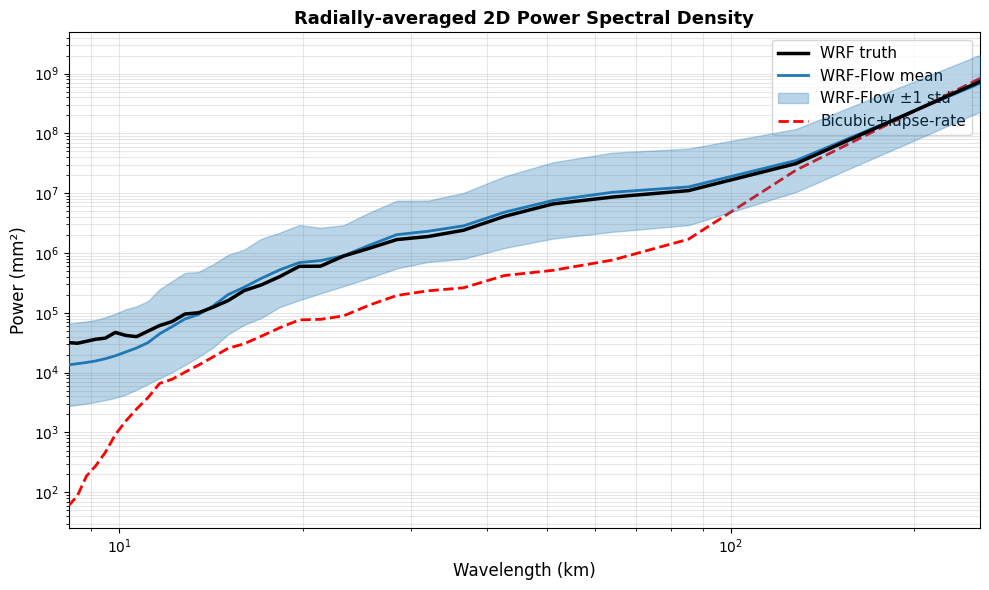


Spectral evaluation (mean absolute log10-error):
  WRF-Flow vs WRF truth:   0.141 (×1.38)
  Bicubic baseline vs WRF: 1.152 (×14.18)
  Spectral improvement:    87.8%

Spectral bias (signed error in log10 space):
  WRF-Flow:   -0.065 (×0.86)
  Bicubic:    -1.148 (×0.07)


In [126]:
def radial_psd(field_2d):
    """
    Compute radially-averaged 2D power spectral density.
    
    Args:
        field_2d: 2D numpy array of shape (n, n), may contain NaNs
    
    Returns:
        wavenumbers: 1D array of wavenumber magnitudes (pixels^-1)
        psd: 1D array of power (units^2, where units are the input field units)
    """
    n = field_2d.shape[0]
    
    # Handle NaN values: replace with field mean (common in spectral analysis)
    field_clean = field_2d.copy()
    nan_mask = np.isnan(field_clean)
    if np.any(nan_mask):
        field_mean = np.nanmean(field_clean)
        field_clean[nan_mask] = field_mean
    
    # Apply 2D Hann window to reduce spectral leakage
    win = np.outer(np.hanning(n), np.hanning(n))
    
    # FFT and power spectral density
    fft2 = np.fft.fftshift(np.fft.fft2(field_clean * win))
    power = np.abs(fft2)**2
    
    # Radial averaging: bin by distance from center
    center = n // 2
    y = np.arange(n) - center
    x = np.arange(n) - center
    yy, xx = np.meshgrid(y, x, indexing='ij')
    r = np.sqrt(xx**2 + yy**2).astype(int)
    
    # Accumulate power in radial bins
    psd = np.bincount(r.ravel(), power.ravel())
    counts = np.bincount(r.ravel())
    psd = psd / np.maximum(counts, 1)  # Avoid division by zero
    
    wavenumbers = np.arange(len(psd))
    
    return wavenumbers[1:n//2], psd[1:n//2]


# Compute PSD for all three models across ensemble members
dx = 4.0  # Grid spacing in km

# Initialize storage for spectra across tiles
k_ref = None
psd_wrf_all = []
psd_flow_all = []
psd_bicubic_all = []

for tile_idx in range(n_tiles):
    # WRF truth spectrum (single realization)
    field_wrf = xtrue_eval[tile_idx, 0].cpu().numpy() * swe_factor
    
    # Skip tiles with too much missing data
    if np.sum(np.isnan(field_wrf)) > 0.5 * n_pix * n_pix:
        print(f"Warning: tile {tile_idx} has >50% NaN coverage, skipping")
        continue
    
    k, psd_wrf = radial_psd(field_wrf)
    if k_ref is None:
        k_ref = k
    psd_wrf_all.append(psd_wrf)
    
    # WRF-Flow ensemble spectra
    psd_flow_members = []
    for member in range(n_eval_samples):
        field_flow = xsamp_ensemble[member, tile_idx, 0].cpu().numpy() * swe_factor
        _, psd_flow = radial_psd(field_flow)
        psd_flow_members.append(psd_flow)
    psd_flow_all.append(np.array(psd_flow_members))
    
    # Bicubic baseline ensemble spectra
    psd_bicubic_members = []
    for member in range(n_eval_samples):
        field_bicubic = xsamp_bicubic[member, tile_idx, 0].cpu().numpy() * swe_factor
        _, psd_bicubic = radial_psd(field_bicubic)
        psd_bicubic_members.append(psd_bicubic)
    psd_bicubic_all.append(np.array(psd_bicubic_members))

# Check that we have valid tiles
if len(psd_wrf_all) == 0:
    print("Error: No valid tiles for spectral analysis!")
else:
    # Average across tiles (geometric mean in log space for better representation)
    psd_wrf_mean = np.exp(np.mean(np.log(np.array(psd_wrf_all) + 1e-10), axis=0))
    psd_flow_ensemble = np.array(psd_flow_all)  # Shape: (n_tiles, n_members, n_wavenumbers)
    psd_flow_mean = np.exp(np.mean(np.log(np.mean(psd_flow_ensemble, axis=1) + 1e-10), axis=0))
    
    # Correct geometric std computation: compute std of log values across all ensemble members (flattened)
    # Reshape to (n_tiles * n_members, n_wavenumbers), then std across first axis
    psd_flow_flat = psd_flow_ensemble.reshape(-1, psd_flow_ensemble.shape[-1])
    psd_flow_logstd = np.std(np.log(psd_flow_flat + 1e-10), axis=0)  # std in log space per wavenumber
    psd_flow_std = np.exp(psd_flow_logstd)  # geometric std factor (multiplier on log plot)
    
    psd_bicubic_ensemble = np.array(psd_bicubic_all)
    psd_bicubic_mean = np.exp(np.mean(np.log(np.mean(psd_bicubic_ensemble, axis=1) + 1e-10), axis=0))
    
    # Convert wavenumber to wavelength in km
    wavelength = (n_pix * dx) / k_ref
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # WRF truth
    ax.loglog(wavelength, psd_wrf_mean, 'k-', linewidth=2.5, label='WRF truth', zorder=10)
    
    # WRF-Flow: mean + ensemble spread
    ax.loglog(wavelength, psd_flow_mean, color='#1f77b4', linewidth=2, label='WRF-Flow mean', zorder=8)
    ax.fill_between(wavelength, 
                     psd_flow_mean / psd_flow_std, 
                     psd_flow_mean * psd_flow_std,
                     alpha=0.3, color='#1f77b4', label='WRF-Flow ±1 std', zorder=7)
    
    # Bicubic baseline
    ax.loglog(wavelength, psd_bicubic_mean, 'r--', linewidth=2, label='Bicubic+lapse-rate', zorder=6)

    #ax.loglog(wavelength,psd_flow_flat.T,'k-',alpha=0.2)
    #ax.loglog(wavelength,np.array(psd_wrf_all).T,'r-')
    
    ax.set_xlabel('Wavelength (km)', fontsize=12)
    ax.set_ylabel('Power (mm²)', fontsize=12)
    ax.set_title('Radially-averaged 2D Power Spectral Density', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='upper right', fontsize=11)
    ax.set_xlim([wavelength[-1], wavelength[0]])  # Right to left: small scale to large scale
    
    plt.tight_layout()
    plt.show()
    
    # Compute log-spectral errors (absolute)
    log_error_flow = np.mean(np.abs(np.log10(psd_flow_mean) - np.log10(psd_wrf_mean)))
    log_error_bicubic = np.mean(np.abs(np.log10(psd_bicubic_mean) - np.log10(psd_wrf_mean)))
    
    print(f"\nSpectral evaluation (mean absolute log10-error):")
    print(f"  WRF-Flow vs WRF truth:   {log_error_flow:.3f} (×{10**log_error_flow:.2f})")
    print(f"  Bicubic baseline vs WRF: {log_error_bicubic:.3f} (×{10**log_error_bicubic:.2f})")
    print(f"  Spectral improvement:    {(log_error_bicubic - log_error_flow) / log_error_bicubic * 100:.1f}%")
    
    # Spectral fidelity and bias: evaluate at multiple thresholds
    log_error_signed_flow = np.log10(psd_flow_mean) - np.log10(psd_wrf_mean)
    bias_flow = np.mean(log_error_signed_flow)  # positive = overpredicting, negative = underpredicting
    
    log_error_signed_bicubic = np.log10(psd_bicubic_mean) - np.log10(psd_wrf_mean)
    bias_bicubic = np.mean(log_error_signed_bicubic)
    
    thresholds = [np.log10(1.1), np.log10(1.25), np.log10(1.5)]  # log10 thresholds: ~10%, 25%, 50% error
    threshold_labels = ["10%", "25%", "50%"]
    
    print(f"\nSpectral bias (signed error in log10 space):")
    print(f"  WRF-Flow:   {bias_flow:+.3f} (×{10**bias_flow:.2f})")
    print(f"  Bicubic:    {bias_bicubic:+.3f} (×{10**bias_bicubic:.2f})")